# Analisis de abandono de clientes
https://www.kaggle.com/datasets/alfathterry/telco-customer-churn-11-1-3?resource=download

Presentado por: Diego Orjuela - Alex Rodriguez - Ana Salcedo

## 1. Configuración Inicial y Adquisición de Datos

In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib

# Gestion de librerias
# ==============================================================================
from importlib import reload

# Matemáticas y estadísticas
# ==============================================================================
import math

# Preparación de datos
# ==============================================================================
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

import matplotlib.pyplot as plt

# Modelado }
#===============================================================================
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
#Configuracion de hiperparámetros
from sklearn.model_selection import ParameterGrid, GridSearchCV, RandomizedSearchCV

#Creación de modelo
from sklearn.ensemble import RandomForestClassifier

# Evaluación del modelo
from sklearn.metrics import classification_report
#Creación de modelo
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

#configuracion de hiperparámetros
# from sklearn.model_selection import GridSearchCV  # This line is redundant, already imported above

#Evaluación del modelo
from sklearn import metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)


#Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/Smartdvis17/Churn/master/'


# Nombres de los archivos requeridos
DATASET_FILE_NAME = 'telco_Prep.csv'  # Incluye la carpeta datasets
UTILS_FILE_NAME = 'funciones.py'         # Incluye la carpeta utils


# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = GITHUB_BASE_URL + 'datasets/' + DATASET_FILE_NAME
github_utils_url = GITHUB_BASE_URL + 'utils/' + UTILS_FILE_NAME

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [3]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [4]:
## Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/Smartdvis17/Churn/master/datasets/telco_Prep.csv
dataset descargado exitosamente a: datasets/telco_Prep.csv
Descargando funciones desde: https://raw.githubusercontent.com/Smartdvis17/Churn/master/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


2. Funciones Auxiliares

In [5]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
sys.path.append(UTILS_PATH)

## Importa Funciones externas
from funciones import multiple_plot

3. Carga e Inspección Inicial de Datos

In [6]:
#Cargar el dataset
df = pd.read_csv(local_dataset_path)

In [7]:
#Previsualización de los datos
df.head(10)

,Gender,Age,Senior Citizen,Married,Number of Dependents,Zip Code,Latitude,Longitude,Population,Referred a Friend,...,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV
0,Male,73,Yes,Yes,0,96145,39.178337,-120.162806,4002,Yes,...,2357.75,0.00,0,1065.75,3423.50,3,Stayed,No,67,2217
1,Male,42,No,No,0,95545,40.342928,-124.063329,82,No,...,19.45,0.00,0,48.96,68.41,2,Churned,Yes,78,5687
2,Male,57,No,Yes,0,95528,40.497283,-123.930370,1072,Yes,...,1125.20,0.00,0,360.99,1486.19,3,Stayed,No,43,5763
3,Female,35,No,No,0,90743,33.728273,-118.085304,174,No,...,578.50,0.00,0,278.10,856.60,3,Stayed,No,78,3986
4,Female,28,No,No,0,92231,32.690654,-115.431225,27804,No,...,1343.40,30.53,0,1549.04,2861.91,5,Stayed,No,72,5462
5,Male,46,No,No,0,90260,33.888560,-118.351813,33300,No,...,19.05,0.00,0,5.02,24.07,4,Joined,No,59,5279
6,Male,30,No,No,0,92251,32.858595,-115.662709,14546,No,...,4964.70,0.00,0,268.65,5233.35,3,Stayed,No,33,5093
7,Male,47,No,No,0,93454,34.943523,-120.256729,30540,No,...,68.20,0.00,0,27.44,95.64,4,Stayed,No,35,2195
8,Female,68,Yes,Yes,0,95726,38.733908,-120.453416,8577,Yes,...,7227.45,0.00,0,994.50,8221.95,3,Stayed,No,39,4452
9,Male,32,No,No,2,91355,34.439870,-118.644609,24977,No,...,1124.20,0.00,0,916.22,2040.42,4,Stayed,No,76,5411


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6326 entries, 0 to 6325
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             6326 non-null   str    
 1   Age                                6326 non-null   int64  
 2   Senior Citizen                     6326 non-null   str    
 3   Married                            6326 non-null   str    
 4   Number of Dependents               6326 non-null   int64  
 5   Zip Code                           6326 non-null   int64  
 6   Latitude                           6326 non-null   float64
 7   Longitude                          6326 non-null   float64
 8   Population                         6326 non-null   int64  
 9   Referred a Friend                  6326 non-null   str    
 10  Number of Referrals                6326 non-null   int64  
 11  Tenure in Months                   6326 non-null   int64  
 12  Off

In [9]:
# Copia del dataset original antes del One-Hot Encoding
# Se usará en el pipeline de oversampling para no modificar df principal
df_over = df.copy()

### Variables de entrada

In [10]:
#Listamos las variables categóricas
catCols = df.select_dtypes(include = ["object", 'category']).columns.tolist()

df[catCols].head(2)

,Gender,Senior Citizen,Married,Referred a Friend,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,...,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status,Churn Label
0,Male,Yes,Yes,Yes,Offer C,Yes,Yes,Yes,Fiber Optic,No,...,No,No,Yes,Yes,Yes,Two Year,Yes,Bank Withdrawal,Stayed,No
1,Male,No,No,No,Offer E,Yes,No,No,No internet,No,...,No,No,No,No,No,Month-to-Month,Yes,Credit Card,Churned,Yes


In [11]:
#Listamos las variables numéricas

numCols=df.select_dtypes(include = ['float64','int32','int64']).columns.tolist()
df[numCols].head()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
0,73,0,96145,39.178337,-120.162806,4002,7,29,36.75,12,84.30,2357.75,0.00,0,1065.75,3423.50,3,67,2217
1,42,0,95545,40.342928,-124.063329,82,0,1,48.96,0,19.45,19.45,0.00,0,48.96,68.41,2,78,5687
2,57,0,95528,40.497283,-123.930370,1072,4,21,17.19,11,54.60,1125.20,0.00,0,360.99,1486.19,3,43,5763
3,35,0,90743,33.728273,-118.085304,174,0,30,9.27,0,19.40,578.50,0.00,0,278.10,856.60,3,78,3986
4,28,0,92231,32.690654,-115.431225,27804,0,67,23.12,0,20.55,1343.40,30.53,0,1549.04,2861.91,5,72,5462


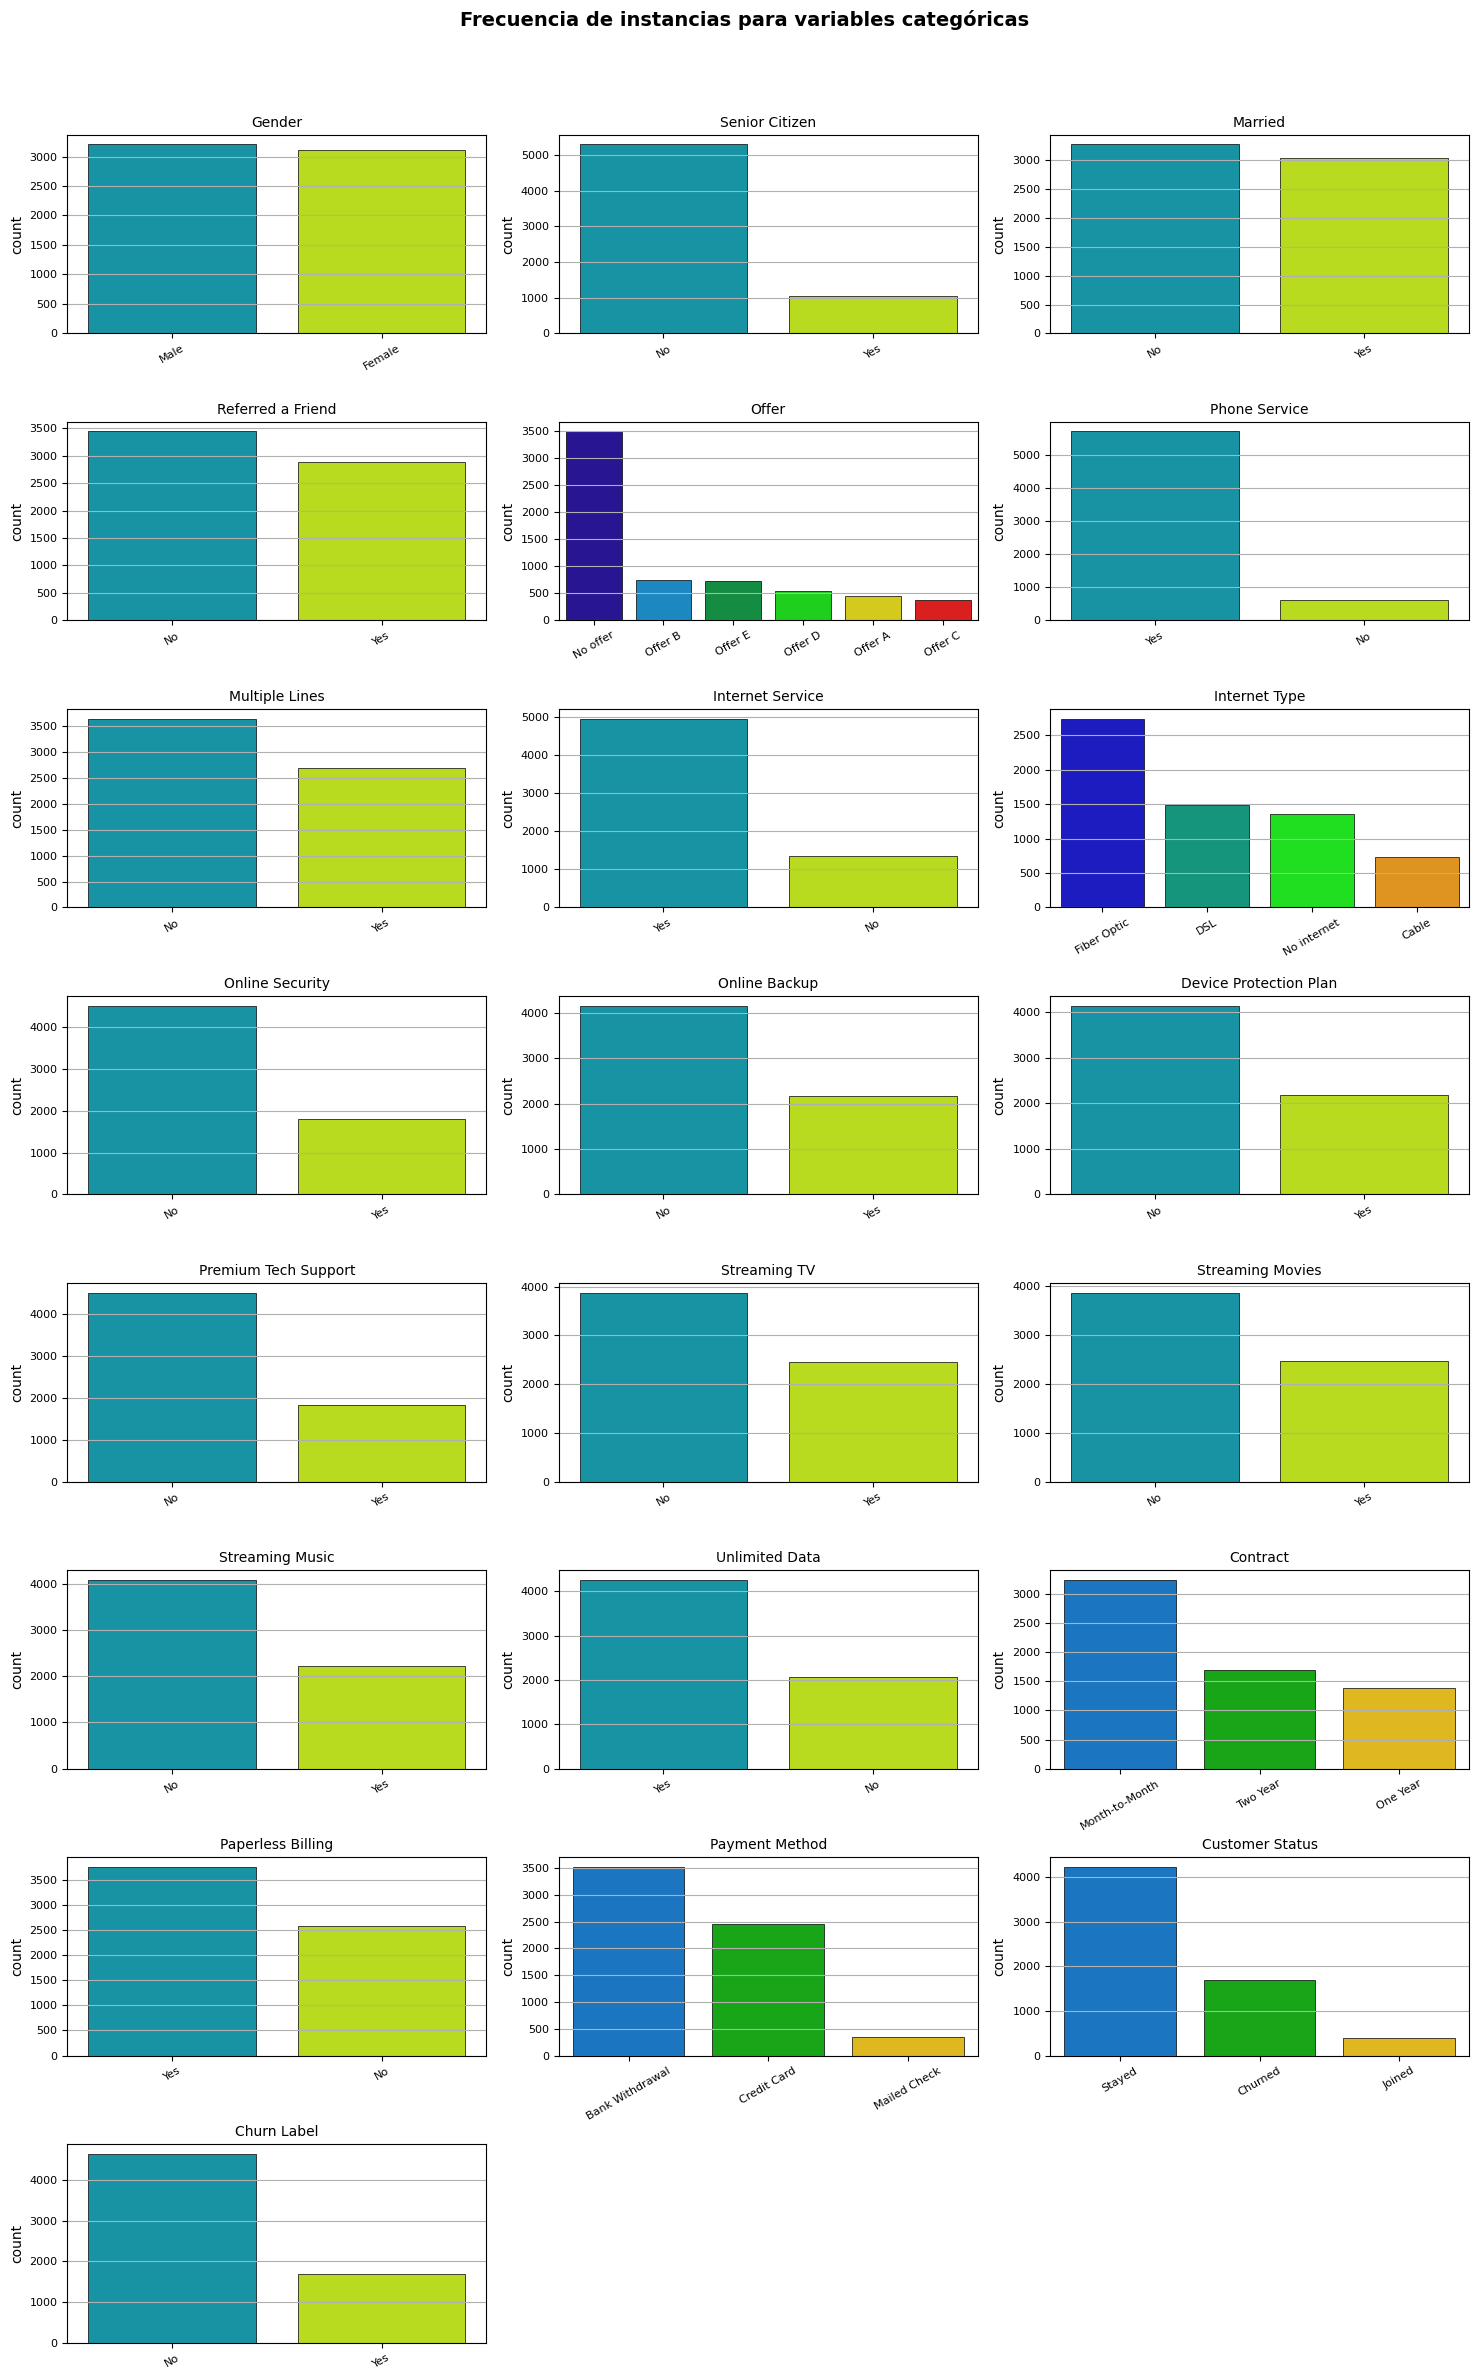

In [12]:
#Visualización de frecuencia de instancias para variables categóricas
multiple_plot(3, df , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

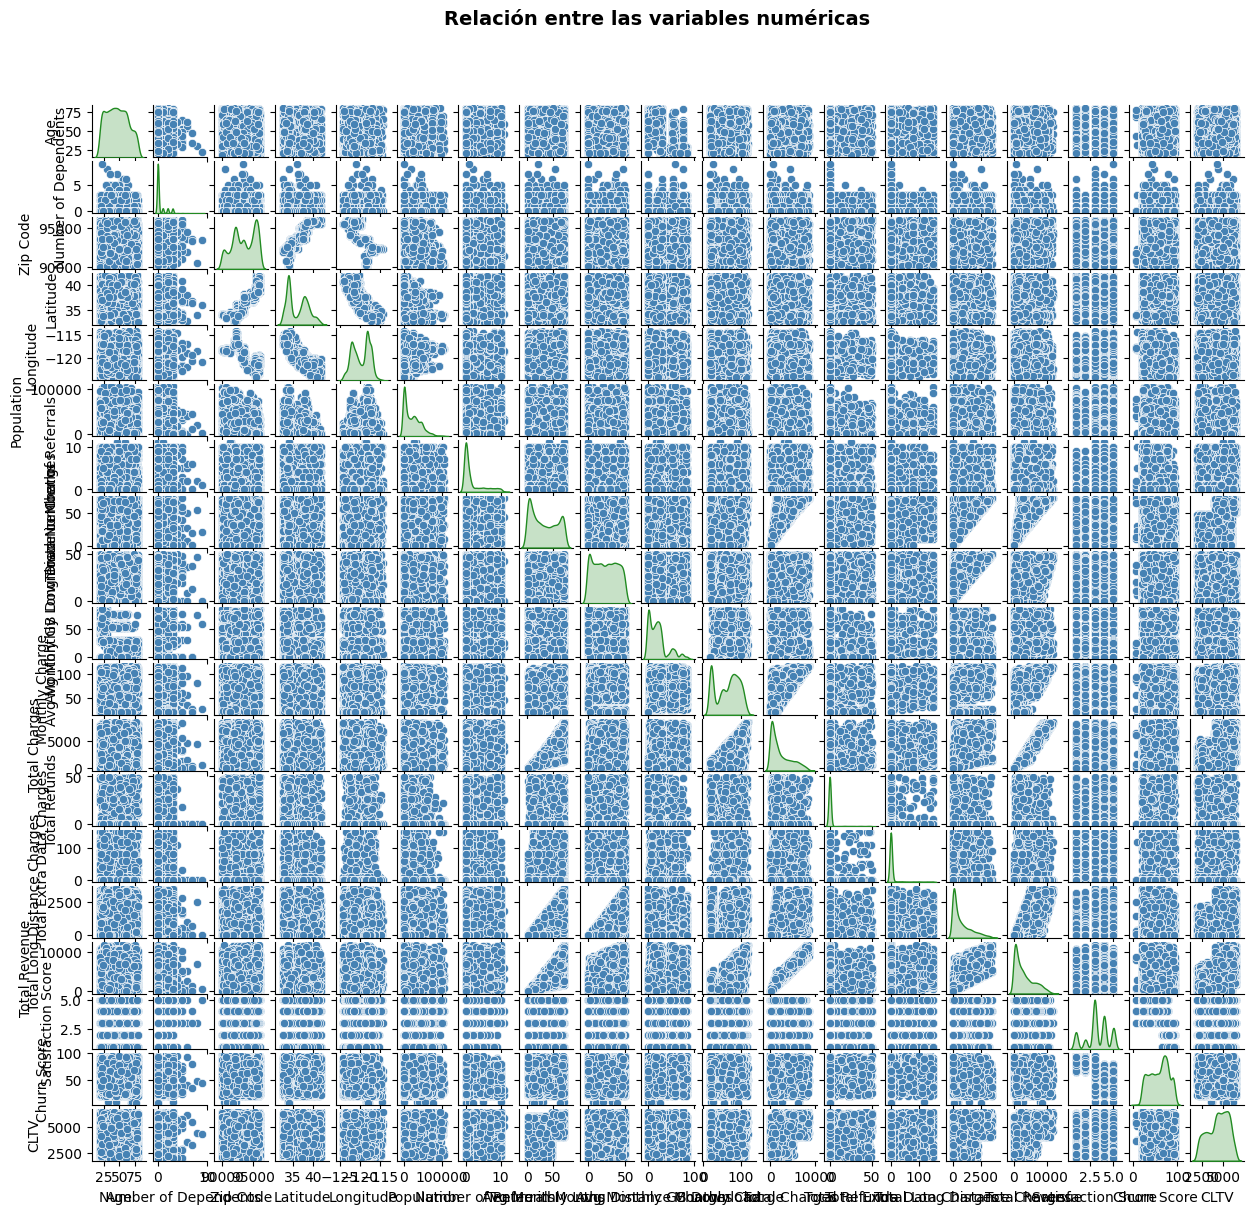

In [13]:
#Visualización de variables numéricas con respecto al precio
multiple_plot(1, df , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

### Variable de salida

In [14]:
df.groupby('Churn Label')['Churn Label'].count().sort_values(ascending=False)

Churn Label
No     4641
Yes    1685
Name: Churn Label, dtype: int64

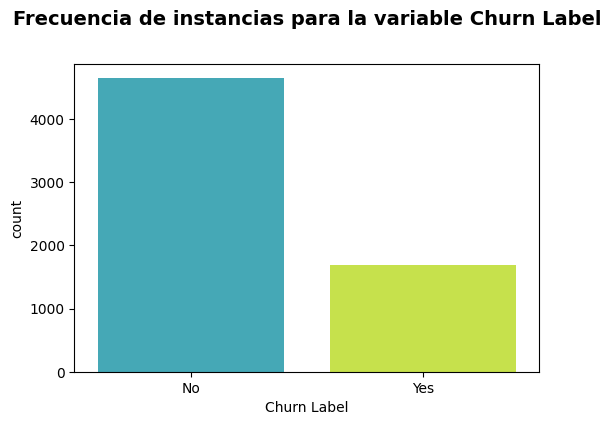

In [15]:
multiple_plot(1, df , None, 'Churn Label', 'countplot', 'Frecuencia de instancias para la variable Churn Label',0)

## 4. Preparación de Datos para el Modelado

### Aplicación de One-Hot Encoding, División, Sobremuestreo y Escalado de Datos

Se aplica One-Hot Encoding al DataFrame completo. Luego, se realiza la división en conjuntos de entrenamiento y prueba.

In [16]:
# Aplicación de la función de usuario Dummies: one-hot encoding al DataFrame completo

df =pd.get_dummies(df, drop_first=1)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6326 entries, 0 to 6325
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                6326 non-null   int64  
 1   Number of Dependents               6326 non-null   int64  
 2   Zip Code                           6326 non-null   int64  
 3   Latitude                           6326 non-null   float64
 4   Longitude                          6326 non-null   float64
 5   Population                         6326 non-null   int64  
 6   Number of Referrals                6326 non-null   int64  
 7   Tenure in Months                   6326 non-null   int64  
 8   Avg Monthly Long Distance Charges  6326 non-null   float64
 9   Avg Monthly GB Download            6326 non-null   int64  
 10  Monthly Charge                     6326 non-null   float64
 11  Total Charges                      6326 non-null   float64
 12  Tot

In [17]:
print('Columnas en df antes de excluir variables:')
print(df.columns.tolist())


Columnas en df antes de excluir variables:
['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV', 'Gender_Male', 'Senior Citizen_Yes', 'Married_Yes', 'Referred a Friend_Yes', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'Phone Service_Yes', 'Multiple Lines_Yes', 'Internet Service_Yes', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Internet Type_No internet', 'Online Security_Yes', 'Online Backup_Yes', 'Device Protection Plan_Yes', 'Premium Tech Support_Yes', 'Streaming TV_Yes', 'Streaming Movies_Yes', 'Streaming Music_Yes', 'Unlimited Data_Yes', 'Contract_One Year', 'Contract_Two Year', 'Paperless Billing_Yes', 'Payment Method_Credit Card'

Excluimos las variables que se consideran de fuga para evitar datalake

In [18]:
# Definimos las variables de entrada (X) y la variable objetivo (y)
exclude = [
    # leakage
    'Churn Score',
    'CLTV',
    'Total Revenue',
    'Customer Status_Joined',
    'Customer Status_Stayed',
    'Satisfaction Score',

    # target
    'Churn Label_Yes',

    # geo noise
    'Zip Code',
    'Latitude',
    'Longitude',
    'Population',
]

X = df.drop(columns=exclude)
y = df['Churn Label_Yes']

vDep = X.columns.tolist()
print('Columnas en X después de excluir variables:', vDep)

Columnas en X después de excluir variables: ['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Gender_Male', 'Senior Citizen_Yes', 'Married_Yes', 'Referred a Friend_Yes', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'Phone Service_Yes', 'Multiple Lines_Yes', 'Internet Service_Yes', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Internet Type_No internet', 'Online Security_Yes', 'Online Backup_Yes', 'Device Protection Plan_Yes', 'Premium Tech Support_Yes', 'Streaming TV_Yes', 'Streaming Movies_Yes', 'Streaming Music_Yes', 'Unlimited Data_Yes', 'Contract_One Year', 'Contract_Two Year', 'Paperless Billing_Yes', 'Payment Method_Credit Card', 'Payment Method_Mailed Check']


In [19]:
# Dividimos los datos en conjuntos de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=123,
    shuffle=True
)


print(f'Shape X_train: {X_train.shape}')
print(f'Shape y_train: {y_train.shape}')
print(f'Shape X_test:  {X_test.shape}')
print(f'Shape y_test:  {y_test.shape}')

Shape X_train: (5060, 39)
Shape y_train: (5060,)
Shape X_test:  (1266, 39)
Shape y_test:  (1266,)


## 5. Escalado de Variables

In [20]:
# Se establecen las variables numéricas a escalar

# Get the list of numerical columns that are actually in X_train
num_vars_to_scale = [col for col in numCols if col in X_train.columns]

print(num_vars_to_scale)

['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges']


In [21]:
# Escalamos Variables Numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars_to_scale] = scaler.fit_transform(X_train[num_vars_to_scale])
X_test[num_vars_to_scale] = scaler.transform(X_test[num_vars_to_scale])

X_test[num_vars_to_scale].head(2)

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges
2579,0.2131,0.0000,0.5455,0.5775,0.0000,0.3059,0.2661,0.2343,0.0000,0.0000,0.0000
1778,0.4426,0.2222,0.3636,0.0845,0.0000,0.3294,0.3114,0.0331,0.0000,0.0000,0.0000


In [22]:
# Guardar el scaler

SCALER_FILE_NAME = 'minmaxFull_Telco.pkl'
local_scaler_path = os.path.join(MODELS_SCALER_PATH, SCALER_FILE_NAME)

joblib.dump(scaler,  local_scaler_path)

['modelos/scaler\\minmaxFull_Telco.pkl']

## 6. Modelado

## Random Forest

## Creación del modelo

### Modelo Base (sin optimización)

Teniendo en cuenta desbalanceo presente en nuestra variable de salida decidimos evaluar el modelo bajo 2 enfoques aplicando los mismos parametros de evaluacion para determinar bajo un ambiente controlado que configuracion nos arroja los mejores resultados aplicando la diferenciacion del balanceo en las diferentes aplicaciones, esto nos dio como resultado la obtencion de mejores metricas en nuestros modelos balanceados.

In [23]:
# Base SIN balanceo — parámetros por defecto
base_unbal = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 5,
    max_features = 'sqrt',
    criterion    = 'gini',
    random_state = 123
)
base_unbal.fit(X_train, y_train)

# Base CON balanceo — mismos parámetros + class_weight
base_bal = RandomForestClassifier(
    n_estimators  = 100,
    max_depth     = 5,
    max_features  = 'sqrt',
    criterion     = 'gini',
    class_weight  = 'balanced',
    random_state  = 123
)
base_bal.fit(X_train, y_train)

print('Modelos baseline entrenados.')
print(f'Train accuracy sin balanceo: {base_unbal.score(X_train, y_train):.4f}')
print(f'Train accuracy con balanceo: {base_bal.score(X_train, y_train):.4f}')


Modelos baseline entrenados.
Train accuracy sin balanceo: 0.8263
Train accuracy con balanceo: 0.7964


In [24]:
# Evaluación de los modelos baseline en el test
separador = '=' * 52

for nombre, mdl in [('Baseline sin balanceo', base_unbal),
                     ('Baseline con balanceo', base_bal)]:
    y_pred = mdl.predict(X_test)
    y_prob = mdl.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)

    print()
    print(separador)
    print(f'  {nombre}')
    print(separador)
    print(classification_report(y_test, y_pred,
                                target_names=['No Churn', 'Churn']))
    print(f'  AUC-ROC: {auc:.4f}')


  Baseline sin balanceo
              precision    recall  f1-score   support

    No Churn       0.84      0.94      0.89       934
       Churn       0.74      0.48      0.59       332

    accuracy                           0.82      1266
   macro avg       0.79      0.71      0.74      1266
weighted avg       0.81      0.82      0.81      1266

  AUC-ROC: 0.8847

  Baseline con balanceo
              precision    recall  f1-score   support

    No Churn       0.93      0.76      0.84       934
       Churn       0.55      0.84      0.67       332

    accuracy                           0.78      1266
   macro avg       0.74      0.80      0.75      1266
weighted avg       0.83      0.78      0.79      1266

  AUC-ROC: 0.8858


## 7. Evaluación Detallada — Modelos Base

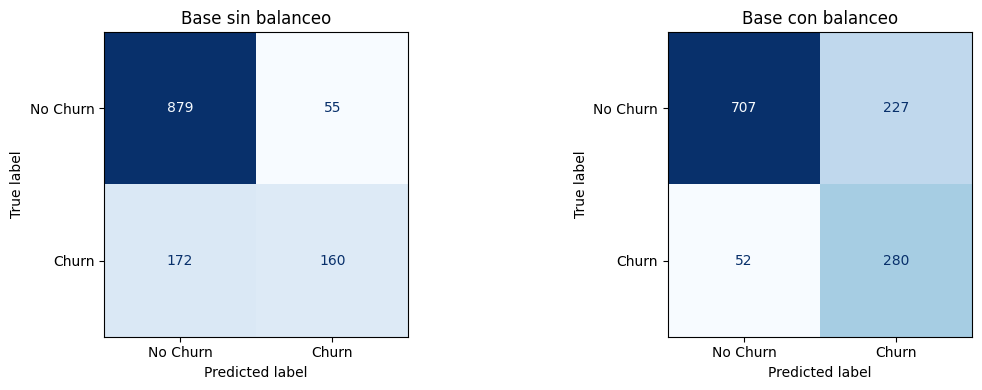

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (nombre, mdl) in zip(axes, [('Base sin balanceo', base_unbal),
                                      ('Base con balanceo', base_bal)]):
    y_pred = mdl.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

### Curvas ROC — Modelos Base

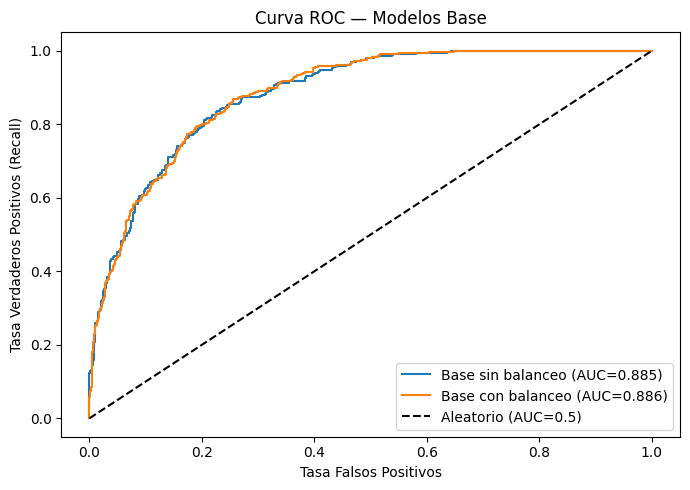

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))

for nombre, mdl in [('Base sin balanceo', base_unbal),
                     ('Base con balanceo', base_bal)]:
    y_prob = mdl.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa Falsos Positivos')
ax.set_ylabel('Tasa Verdaderos Positivos (Recall)')
ax.set_title('Curva ROC — Modelos Base')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Optimización con Grid Search (OOB — Recall)

En términos generales, los modelos base presentan los siguientes comportamientos:

- **Sin balanceo**: Obtenemos alta accuracy global, pero recall bajo para Churn. El modelo predice mayoritariamente "No Churn" por el desbalanceo 73/27%.
- **Con balanceo** : sacrificamos accuracy para ganar recall en la clase minoritaria. Detectamos más churners a costa de más alarmas falsas.

- Usamos oob por que al intentar con cv nos tomo mucho tiempo de ejecucion y oob nos funciono mejor tambien intentamos añadir los siguientes parametros      'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], para determinar si nos podian reflejar una optimizacion del modelo sin embargo el tiempo de respuesta no fue optimo (+7 min) y decidimos desestimar estos datos y trabajar solo con los siguientes parametros con los que tardamos alrededor de 3 min en ejecucion.
      'n_estimators': [100, 150, 200],
      'max_features': ['sqrt', 'log2', 5, 7, 9],
      'max_depth': [5, 10, 15],  
      'criterion': ['gini', 'entropy'],

Inicialmente consideramos solo priorizar recall, por el objetivo de nuestro modelo, sin embargo luego consideramos encontrar una relacion mas estable entre recall y f1 score por lo que decidimos apuntar hacia una estrategis mas equilibrada optimizando el umbral de decision (threshold) y la evaluacion combinada del recall y f1 score.

Con la optimizacion implemetada al final obtuvimos un cambio en  nuestros mejores hyperparametros iniciales y aunque los resultado no arrojan mayore diferencias con respecto al modelo anterior tenemos una relacion mas equilibrada entre nuestro f1 score y recall

Tambien ensayamos aplicando balanceo con oversamplig pero finalmente decidimos no incluirlos por que nos generaba un poco de sobreajuste y los resultados no representaban gran diferencia con los modelos y parametros aplicados actualmente.

Mejores hyperparametros antes

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 9, 'n_estimators': 200}
Recall OOB balanceado:    0.8618

Mejores hyperparametros ahora

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'log2', 'n_estimators': 200}
Recall OOB balanceado:    0.8507

In [27]:
# Definición del grid de parámetros
param_grid = ParameterGrid(
    {
        'n_estimators': [100, 150, 200],
        'max_features': ['sqrt', 'log2', 5, 7, 9],
        'max_depth': [5, 10, 15],
        'criterion': ['gini', 'entropy'],
    }
)

thresholds = [0.3, 0.4, 0.5]

# Diccionario de resultados
resultados = {
    'params': [],
    'threshold': [],
    'recall_oob_bal': [],
    'f1_oob_bal': [],
    'score_bal': [],
    'train_bal': [],
    'gap_bal': []
}

for params in param_grid:

    # ── Modelo CON balanceo ───────────────────────────────────────────
    m_bal = RandomForestClassifier(
        class_weight='balanced',
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=123,
        **params
    )

    m_bal.fit(X_train, y_train)

    # ── PROBABILIDADES OOB ───────────────────────────────────────────
    oob_probs = m_bal.oob_decision_function_[:, 1]

    # ── BÚSQUEDA DE MEJOR THRESHOLD ──────────────────────────────────
    for t in thresholds:

        oob_preds_bal = (oob_probs >= t).astype(int)

        recall_bal = recall_score(y_train, oob_preds_bal)
        f1_bal = f1_score(y_train, oob_preds_bal)

        score_bal = 0.5 * recall_bal + 0.5 * f1_bal

        resultados['params'].append(params)
        resultados['threshold'].append(t)
        resultados['recall_oob_bal'].append(recall_bal)
        resultados['f1_oob_bal'].append(f1_bal)
        resultados['score_bal'].append(score_bal)

        resultados['train_bal'].append(m_bal.score(X_train, y_train))
        resultados['gap_bal'].append(m_bal.score(X_train, y_train) - m_bal.oob_score_)

print('Grid Search OOB Recall + F1 + Threshold completado.')

Grid Search OOB Recall + F1 + Threshold completado.


In [28]:
resultadosDf = pd.DataFrame({k: v for k, v in resultados.items() if len(v) > 0})
resultadosDf = pd.concat(
    [resultadosDf, resultadosDf['params'].apply(pd.Series)], axis=1
)
resultadosDf = resultadosDf.drop(columns='params')

# Ordenar por Recall OOB balanceado descendente, gap ascendente
resultadosDf = resultadosDf.sort_values(
    by=['recall_oob_bal', 'gap_bal'],
    ascending=[False, True]
)

resultadosDf[['criterion','max_depth','max_features','n_estimators',
              'recall_oob_bal','gap_bal',]].head(10)

,criterion,max_depth,max_features,n_estimators,recall_oob_bal,gap_bal
150,entropy,5,log2,200,0.9667,0.0119
159,entropy,5,5,200,0.9667,0.0119
144,entropy,5,log2,100,0.9660,0.0097
153,entropy,5,5,100,0.9660,0.0097
147,entropy,5,log2,150,0.9660,0.0113
156,entropy,5,5,150,0.9660,0.0113
15,gini,5,log2,200,0.9645,0.0140
24,gini,5,5,200,0.9645,0.0140
6,gini,5,sqrt,200,0.9638,0.0107
138,entropy,5,sqrt,150,0.9638,0.0111


In [29]:
# Filtrar combinaciones con gap < 0.07 (control de overfitting)
# gap = train_accuracy - oob_accuracy: mide cuánto memoriza el modelo
resultados_filtrados = resultadosDf[resultadosDf['gap_bal'] < 0.07]

resultados_filtrados[['criterion','max_depth','max_features','n_estimators',
                       'recall_oob_bal','gap_bal']].head(10)

,criterion,max_depth,max_features,n_estimators,recall_oob_bal,gap_bal
150,entropy,5,log2,200,0.9667,0.0119
159,entropy,5,5,200,0.9667,0.0119
144,entropy,5,log2,100,0.9660,0.0097
153,entropy,5,5,100,0.9660,0.0097
147,entropy,5,log2,150,0.9660,0.0113
156,entropy,5,5,150,0.9660,0.0113
15,gini,5,log2,200,0.9645,0.0140
24,gini,5,5,200,0.9645,0.0140
6,gini,5,sqrt,200,0.9638,0.0107
138,entropy,5,sqrt,150,0.9638,0.0111


In [30]:
# Mejores hiperparámetros: mayor Recall OOB con gap < 0.07
best_row = resultados_filtrados.iloc[0]
best_hyperparameters = {
    'criterion'   : best_row['criterion'],
    'max_depth'   : int(best_row['max_depth']),
    'max_features': best_row['max_features'],
    'n_estimators': int(best_row['n_estimators'])
}
print('Mejores hiperparámetros:', best_hyperparameters)

# Modelo final CON balanceo
modelo = RandomForestClassifier(
    **best_hyperparameters,
    class_weight='balanced',
    bootstrap=True, oob_score=True,
    n_jobs=-1, random_state=123
)
modelo.fit(X_train, y_train)

# Modelo final SIN balanceo
# modelo_unbal = RandomForestClassifier(
#     **best_hyperparameters,
#     bootstrap=True, oob_score=True,
#     n_jobs=-1, random_state=123
# )
# modelo_unbal.fit(X_train, y_train)

# Recall OOB (criterio de selección) — solo usa y_train
oob_pred_bal   = (modelo.oob_decision_function_[:, 1]   >= 0.5).astype(int)
#oob_pred_unbal = (modelo_unbal.oob_decision_function_[:, 1] >= 0.5).astype(int)

print(f'Recall OOB balanceado:    {recall_score(y_train, oob_pred_bal):.4f}')
#print(f'Recall OOB no balanceado: {recall_score(y_train, oob_pred_unbal):.4f}')

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'log2', 'n_estimators': 200}
Recall OOB balanceado:    0.8507


## 9. Evaluación — Modelos Optimizados

In [31]:
# Modelos finales ya entrenados en celda 39:
# - modelo       → con class_weight='balanced'
# - modelo_unbal → sin class_weight
print('modelo:      ', modelo)
#print('modelo_unbal:', modelo_unbal)

modelo:       RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, max_features='log2', n_estimators=200,
                       n_jobs=-1, oob_score=True, random_state=123)


### Evaluación

In [32]:
separador  = '=' * 55
separador2 = '-' * 55

for nombre, mdl in [ ('Con balanceo', modelo)]:
    y_pred = mdl.predict(X_test)
    y_prob = mdl.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)

    # Métricas individuales
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    # Matriz de confusión → TP, TN, FP, FN
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total = tn + fp + fn + tp

    print()
    print(separador)
    print(f'  MODELO: {nombre}')
    print(separador)

    # --- Reporte completo ---
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    # --- Métricas globales ---
    print(separador2)
    print('  MÉTRICAS GLOBALES')
    print(separador2)
    print(f'  Accuracy  : {acc:.4f}  → De cada 100 clientes, el modelo acierta ~{acc*100:.1f}')
    print(f'  Precision : {prec:.4f}  → De los clientes que predice como Churn, {prec*100:.1f}% realmente se van')
    print(f'  Recall    : {rec:.4f}  → Detecta el {rec*100:.1f}% de todos los clientes que realmente hacen Churn')
    print(f'  F1-Score  : {f1:.4f}  → Balance entre Precision y Recall')
    print(f'  AUC-ROC   : {auc:.4f}  → Capacidad de separar Churn vs No Churn (1=perfecto, 0.5=aleatorio)')

    # --- Matriz de confusión detallada ---
    print()
    print(separador2)
    print('  MATRIZ DE CONFUSIÓN DETALLADA')
    print(separador2)
    print(f'  Verdaderos Negativos (TN): {tn:4d}  → No Churn correctamente identificados')
    print(f'  Falsos Positivos     (FP): {fp:4d}  → No Churn clasificados como Churn  (Alarma falsa)')
    print(f'  Falsos Negativos     (FN): {fn:4d}  → Churn NO detectados                (Error crítico)')
    print(f'  Verdaderos Positivos (TP): {tp:4d}  → Churn correctamente identificados')
    print()
    print(f'  Tasa de error global      : {(fp+fn)/total*100:.1f}%')
    print(f'  Churn no detectado (FNR)  : {fn/(fn+tp)*100:.1f}%  — clientes perdidos sin aviso')
    print(f'  Alarmas falsas     (FPR)  : {fp/(fp+tn)*100:.1f}%  — recursos gastados en falsos positivos')
    print(separador)



  MODELO: Con balanceo
              precision    recall  f1-score   support

    No Churn       0.94      0.76      0.84       934
       Churn       0.56      0.85      0.67       332

    accuracy                           0.78      1266
   macro avg       0.75      0.81      0.76      1266
weighted avg       0.84      0.78      0.79      1266

-------------------------------------------------------
  MÉTRICAS GLOBALES
-------------------------------------------------------
  Accuracy  : 0.7828  → De cada 100 clientes, el modelo acierta ~78.3
  Precision : 0.5560  → De los clientes que predice como Churn, 55.6% realmente se van
  Recall    : 0.8524  → Detecta el 85.2% de todos los clientes que realmente hacen Churn
  F1-Score  : 0.6730  → Balance entre Precision y Recall
  AUC-ROC   : 0.8869  → Capacidad de separar Churn vs No Churn (1=perfecto, 0.5=aleatorio)

-------------------------------------------------------
  MATRIZ DE CONFUSIÓN DETALLADA
----------------------------------

### Matrices de Confusión

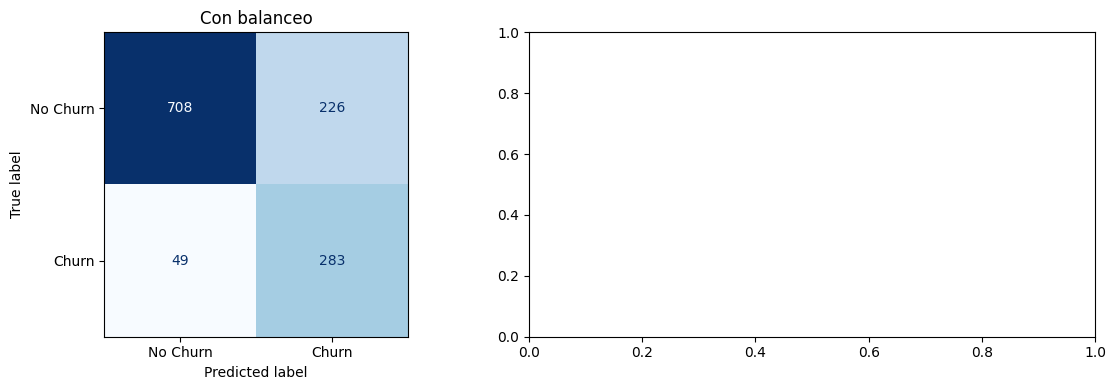

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (nombre, mdl) in zip(axes, [
                                      ('Con balanceo', modelo)]):
    y_pred = mdl.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

### Curvas ROC

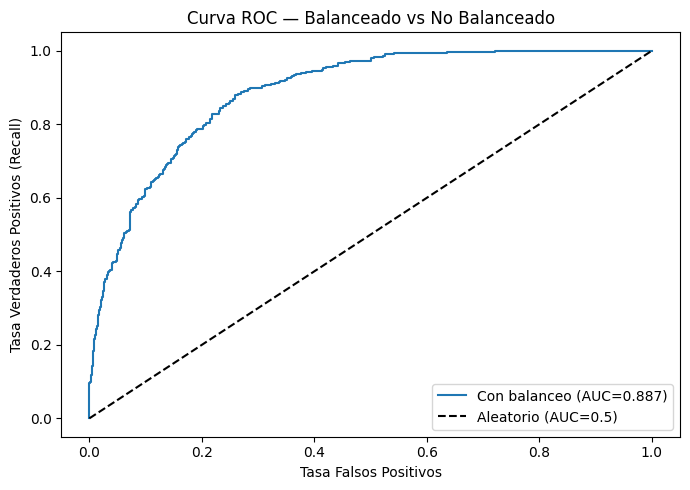

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))

for nombre, mdl in [ ('Con balanceo', modelo)]:
    y_prob = mdl.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa Falsos Positivos')
ax.set_ylabel('Tasa Verdaderos Positivos (Recall)')
ax.set_title('Curva ROC — Balanceado vs No Balanceado')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Comparativa Final — Todos los Modelos

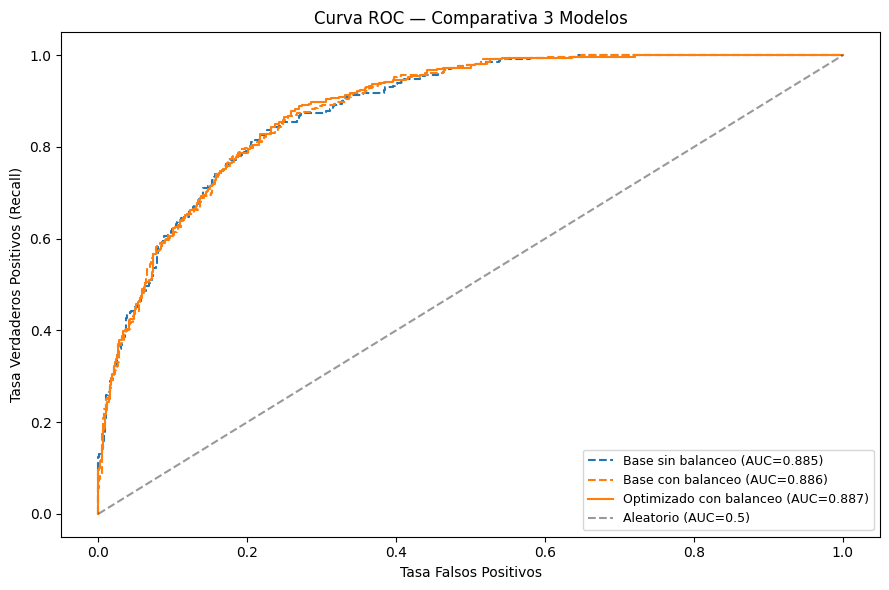

In [35]:
# Curvas ROC de los 5 modelos en un solo grafico
fig, ax = plt.subplots(figsize=(9, 6))

modelos_comparativa = [
    ('Base sin balanceo',        base_unbal,   X_test,      y_test,      'C0', '--'),
    ('Base con balanceo',        base_bal,     X_test,      y_test,      'C1', '--'),
    #('Optimizado sin balanceo',  modelo_unbal, X_test,      y_test,      'C0', '-'),
    ('Optimizado con balanceo',  modelo,       X_test,      y_test,      'C1', '-'),

]

for nombre, mdl, X_ev, y_ev, color, estilo in modelos_comparativa:
    y_prob = mdl.predict_proba(X_ev)[:, 1]
    fpr, tpr, _ = roc_curve(y_ev, y_prob)
    auc = roc_auc_score(y_ev, y_prob)
    ax.plot(fpr, tpr, color=color, linestyle=estilo,
            label=f'{nombre} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa Falsos Positivos')
ax.set_ylabel('Tasa Verdaderos Positivos (Recall)')
ax.set_title('Curva ROC — Comparativa 3 Modelos')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Tabla Comparativa de Métricas

De acuerdo con el objetivo de nuestro modelado que es detectar la mayor cantidad de posibles clientes que abandonan identificamos que de acuerdo con los entrenamientos y pruebas realizadas nuesto mejor modelo es Random Forest con OOB y a su vez tambien por su eficiencia en los tiempos de respuesta.

In [36]:
separador  = '=' * 130
separador2 = '-' * 130

modelos_comparativa = [
    ('Baseline',     'Base sin balanceo',  base_unbal,   X_test,      y_test),
    ('Baseline',     'Base con balanceo',  base_bal,     X_test,      y_test),
    #('Optimizado',   'Opt. sin balanceo',  modelo_unbal, X_test,      y_test),
    ('Optimizado',   'Opt. con balanceo',  modelo,       X_test,      y_test),

]

# Calcular métricas para todos los modelos
resultados_finales = []
for grupo, nombre, mdl, X_ev, y_ev in modelos_comparativa:
    y_pred = mdl.predict(X_ev)
    y_prob = mdl.predict_proba(X_ev)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_ev, y_pred).ravel()
    resultados_finales.append({
        'grupo' : grupo,
        'nombre': nombre,
        'mdl'   : mdl,
        'X_ev'  : X_ev,
        'y_ev'  : y_ev,
        'acc'   : accuracy_score(y_ev, y_pred),
        'prec'  : precision_score(y_ev, y_pred),
        'rec'   : recall_score(y_ev, y_pred),
        'f1'    : f1_score(y_ev, y_pred),
        'auc'   : roc_auc_score(y_ev, y_prob),
        'tp'    : tp,
        'fn'    : fn,
        'fp'    : fp,
        'total_churn': tp + fn,
    })

# Identificar el mejor modelo por Recall (objetivo del proyecto)
mejor_recall = max(resultados_finales, key=lambda x: x['rec'])
mejor_f1     = max(resultados_finales, key=lambda x: x['f1'])
mejor_auc    = max(resultados_finales, key=lambda x: x['auc'])

def generar_obs(r, mejor_recall, mejor_f1, mejor_auc):
    tags = []
    if r['nombre'] == mejor_recall['nombre']:
        tags.append(f'MAYOR RECALL ({r["rec"]*100:.1f}%)')
    if r['nombre'] == mejor_f1['nombre']:
        tags.append(f'MAYOR F1 ({r["f1"]:.4f})')
    if r['nombre'] == mejor_auc['nombre']:
        tags.append(f'MAYOR AUC ({r["auc"]:.4f})')

    churn_detectados = r['tp']
    churn_perdidos   = r['fn']
    pct_detectados   = r['rec'] * 100

    obs = f'Detecta {churn_detectados}/{r["total_churn"]} churners ({pct_detectados:.1f}%). '
    obs += f'Alarmas falsas: {r["fp"]}. '
    if tags:
        obs += '>>> ' + ' | '.join(tags)
    return obs

col = '{:<14} {:<22} {:>9} {:>10} {:>8} {:>8} {:>8}  {}'
print(separador)
print('  COMPARATIVA FINAL - TODOS LOS MODELOS  (ordenado por Recall)')
print(separador)
print('  ' + col.format('Grupo', 'Modelo', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'Observaciones'))
print(separador2)

for r in sorted(resultados_finales, key=lambda x: x['rec'], reverse=True):
    obs = generar_obs(r, mejor_recall, mejor_f1, mejor_auc)
    print('  ' + col.format(r['grupo'], r['nombre'],
                             f'{r["acc"]:.4f}', f'{r["prec"]:.4f}',
                             f'{r["rec"]:.4f}', f'{r["f1"]:.4f}',
                             f'{r["auc"]:.4f}', obs))

print(separador)
print(f'  Modelo con mayor Recall : {mejor_recall["nombre"]} ({mejor_recall["rec"]*100:.1f}%)')
print(f'  Modelo con mayor F1     : {mejor_f1["nombre"]} ({mejor_f1["f1"]:.4f})')
print(f'  Modelo con mayor AUC    : {mejor_auc["nombre"]} ({mejor_auc["auc"]:.4f})')
print(separador)

  COMPARATIVA FINAL - TODOS LOS MODELOS  (ordenado por Recall)
  Grupo          Modelo                  Accuracy  Precision   Recall       F1      AUC  Observaciones
----------------------------------------------------------------------------------------------------------------------------------
  Optimizado     Opt. con balanceo         0.7828     0.5560   0.8524   0.6730   0.8869  Detecta 283/332 churners (85.2%). Alarmas falsas: 226. >>> MAYOR RECALL (85.2%) | MAYOR F1 (0.6730) | MAYOR AUC (0.8869)
  Baseline       Base con balanceo         0.7796     0.5523   0.8434   0.6675   0.8858  Detecta 280/332 churners (84.3%). Alarmas falsas: 227. 
  Baseline       Base sin balanceo         0.8207     0.7442   0.4819   0.5850   0.8847  Detecta 160/332 churners (48.2%). Alarmas falsas: 55. 
  Modelo con mayor Recall : Opt. con balanceo (85.2%)
  Modelo con mayor F1     : Opt. con balanceo (0.6730)
  Modelo con mayor AUC    : Opt. con balanceo (0.8869)


### Verificación de Overfitting — Train vs Test Accuracy

Dentro de la evaluacion no observamos señales de overfitting alarmantes.

In [37]:
def nivel_overfit(diff):
    if diff <= 0.01: return 'Sin overfitting'
    if diff <= 0.03: return 'Overfitting leve'
    if diff <= 0.05: return 'Overfitting moderado'
    return 'Overfitting alto'

modelos_overfit = [
    ('Base sin balanceo',        base_unbal,   X_train,     y_train,     X_test,      y_test),
    ('Base con balanceo',        base_bal,     X_train,     y_train,     X_test,      y_test),
    #('Optimizado sin balanceo',  modelo_unbal, X_train,     y_train,     X_test,      y_test),
    ('Optimizado con balanceo',  modelo,       X_train,     y_train,     X_test,      y_test),

]

print(f"  {'Modelo':<28} {'Train Acc':>10} {'Test Acc':>10} {'Diferencia':>12} {'Observacion':<22}")
print(f"  {'-'*28} {'-'*10} {'-'*10} {'-'*12} {'-'*22}")

for nombre, mdl, X_tr, y_tr, X_te, y_te in modelos_overfit:
    tr_acc = accuracy_score(y_tr, mdl.predict(X_tr))
    te_acc = accuracy_score(y_te, mdl.predict(X_te))
    diff   = tr_acc - te_acc
    print(f"  {nombre:<28} {tr_acc:>10.4f} {te_acc:>10.4f} {diff:>12.4f} {nivel_overfit(diff):<22}")

  Modelo                        Train Acc   Test Acc   Diferencia Observacion           
  ---------------------------- ---------- ---------- ------------ ----------------------
  Base sin balanceo                0.8263     0.8207       0.0056 Sin overfitting       
  Base con balanceo                0.7964     0.7796       0.0168 Overfitting leve      
  Optimizado con balanceo          0.7933     0.7828       0.0105 Overfitting leve      


## 12. Exportación de Modelos

Se exportan todos los modelos entrenados en formato `.pkl` usando `joblib`.

In [38]:
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)

modelos_export = {
    'RForest_base_unbal.pkl'    : base_unbal,
    'RForest_base_bal.pkl'      : base_bal,
    #'RForest_recall_unbal.pkl'  : modelo_unbal,
    'RForest_recall_bal.pkl'    : modelo,

}

for nombre_archivo, mdl in modelos_export.items():
    ruta = os.path.join(MODELS_CLASIFICACION_PATH, nombre_archivo)
    joblib.dump(mdl, ruta)
    print(f'Guardado: {ruta}')

Guardado: modelos/clasificacion\RForest_base_unbal.pkl
Guardado: modelos/clasificacion\RForest_base_bal.pkl
Guardado: modelos/clasificacion\RForest_recall_bal.pkl
